# HVAC Electricity Demand analysis and prediction


## 2.2 Filtering Time series analysis

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# ARIMA
from pmdarima.arima import auto_arima

# Statsmodels
import statsmodels.api as sm
import statsmodels.formula as smf
import statsmodels.tsa as smt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from pmdarima.model_selection import train_test_split

# Filter
from scipy.signal import savgol_filter
import multiprocessing

np.random.seed(42)

In [2]:
df_daily = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)

In [3]:
df_filtered = df_daily["2017-06-01":"2018-06-30"]
train = df_filtered["electricity_demand_values"]
test = df_daily["2017-07-01":"2018-07-31"]["electricity_demand_values"]

In [4]:
model = auto_arima(
    train,
    seasonal=True,
    m=365,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[365] intercept   : AIC=inf, Time=1328.83 sec
 ARIMA(0,1,0)(0,0,0)[365] intercept   : AIC=7131.034, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[365] intercept   : AIC=inf, Time=399.86 sec
 ARIMA(0,1,1)(0,0,1)[365] intercept   : AIC=inf, Time=920.71 sec
 ARIMA(0,1,0)(0,0,0)[365]             : AIC=7129.064, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[365] intercept   : AIC=inf, Time=1387.91 sec
 ARIMA(0,1,0)(0,0,1)[365] intercept   : AIC=inf, Time=1160.08 sec
 ARIMA(0,1,0)(1,0,1)[365] intercept   : AIC=inf, Time=2450.98 sec
 ARIMA(1,1,0)(0,0,0)[365] intercept   : AIC=7128.123, Time=0.01 sec
 ARIMA(1,1,0)(0,0,1)[365] intercept   : AIC=inf, Time=1163.53 sec
 ARIMA(1,1,0)(1,0,1)[365] intercept   : AIC=inf, Time=988.24 sec
 ARIMA(2,1,0)(0,0,0)[365] intercept   : AIC=7091.641, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[365] intercept   : AIC=inf, Time=510.74 sec
 ARIMA(2,1,0)(0,0,1)[365] intercept   : AIC=inf, Time=158.71 sec
 ARIMA(2,1,0)(1,0,1)[365] inte

: 

In [ ]:
# 拟合模型
model.fit(train)

# 进行预测
forecast = model.predict(n_periods=len(test))

In [ ]:
# 计算评估指标
rmse = mean_squared_error(test, forecast, squared=False)
r2 = r2_score(test, forecast)
mae = np.mean(np.abs(forecast - test))
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

In [ ]:
# 输出模型摘要和评估指标
print(model.summary())

In [144]:
# 选择目标列进行ARIMA模型分析
series = df_daily["electricity_demand_values"]

In [145]:
# # 季节性分解
# result = seasonal_decompose(series, model="additive", period=365)

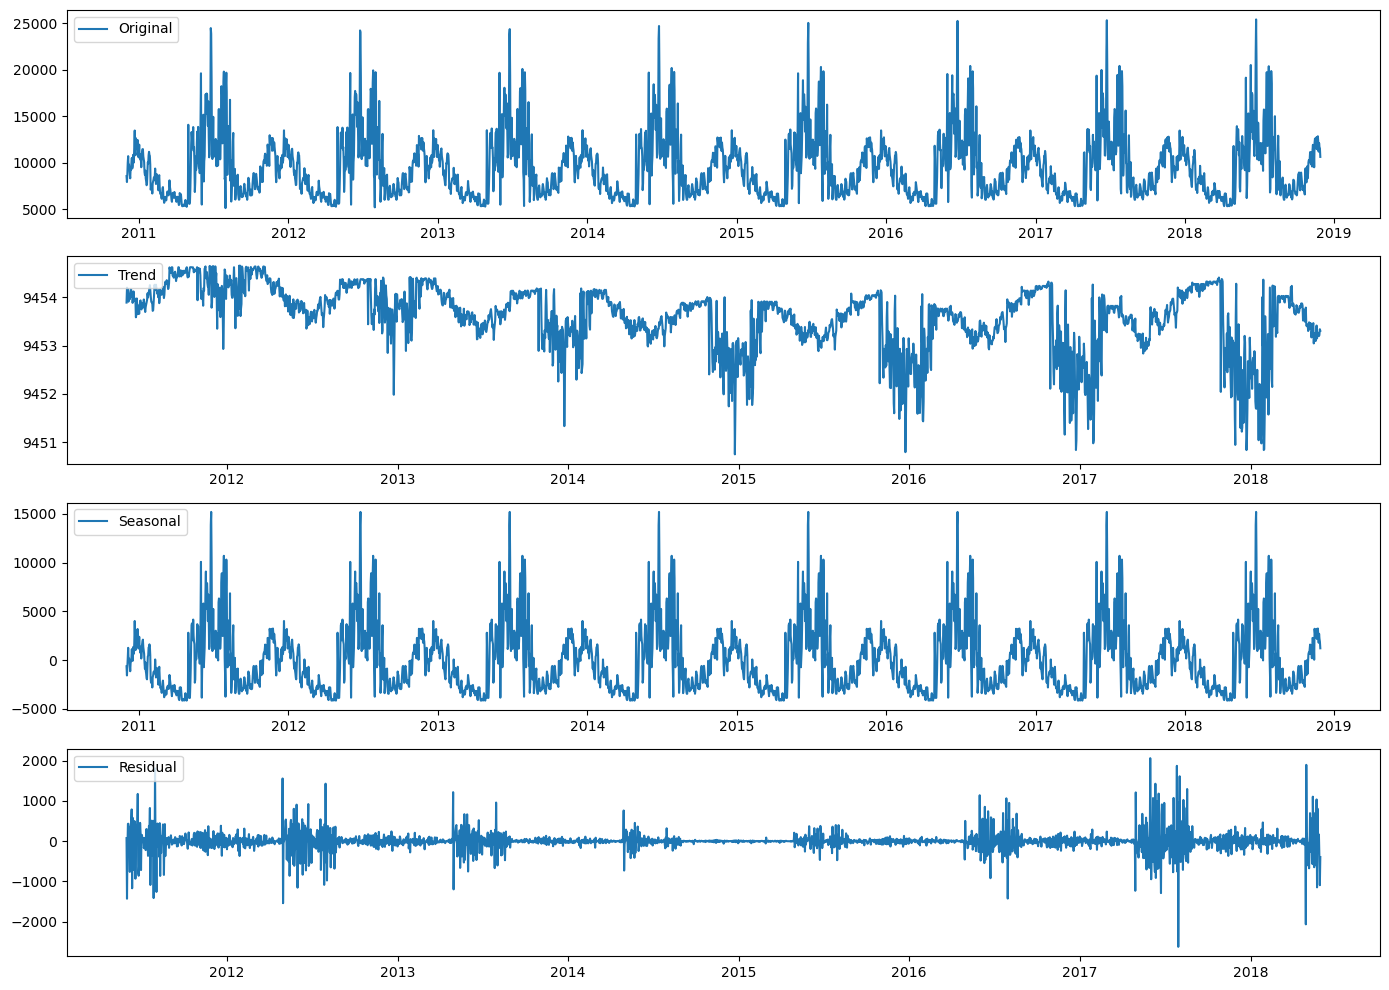

In [146]:
# # 绘制分解结果
# plt.figure(figsize=(14, 10))
# plt.subplot(411)
# plt.plot(result.observed, label="Original")
# plt.legend(loc="upper left")
# plt.subplot(412)
# plt.plot(result.trend, label="Trend")
# plt.legend(loc="upper left")
# plt.subplot(413)
# plt.plot(result.seasonal, label="Seasonal")
# plt.legend(loc="upper left")
# plt.subplot(414)
# plt.plot(result.resid, label="Residual")
# plt.legend(loc="upper left")
# plt.tight_layout()
# plt.show()